## Problema - Sistema de atención de una tienda

**Objetivo:** diseñar un sistema que permita administrar clientes, registrar las atenciones realizadas y mantener un catálogo de productos.

Se utilizan tres estructuras de datos:
- **Cola (FIFO):** clientes que esperan ser atendidos.
- **Pila (LIFO):** historial de clientes atendidos para poder deshacer la última atención.
- **Lista doblemente enlazada:** catálogo de productos, permitiendo recorrerlo en ambos sentidos y buscar/eliminar productos.


In [ ]:
nombre_estudiante = "Juan Pablo Leon Davila"
carnet = 1000114216


## 1) Descripción del problema **[1 pts]**

La tienda necesita organizar la atención de sus clientes y administrar su catálogo. Los clientes deben ser atendidos en el mismo orden en que llegan, por lo que se requiere una **cola FIFO**. Cada cliente atendido debe quedar registrado en un historial y la última atención debe poder deshacerse, por lo que se utiliza una **pila LIFO**. Además, los productos deben almacenarse en una **lista doblemente enlazada** para poder recorrer el catálogo desde el primer producto hasta el último y también en sentido contrario.

El sistema debe permitir registrar y atender clientes, deshacer la última atención y realizar operaciones básicas sobre los productos, como agregar, recorrer, buscar y eliminar.


## 2) Requerimientos **[2 pts]**

### Requerimientos Funcionales:
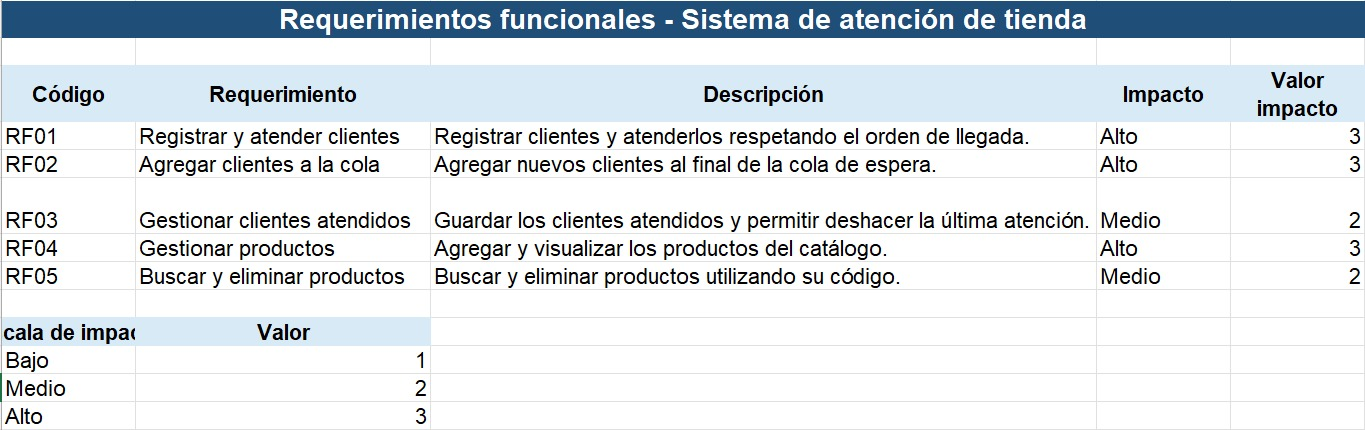



### Requerimientos No Funcionales:
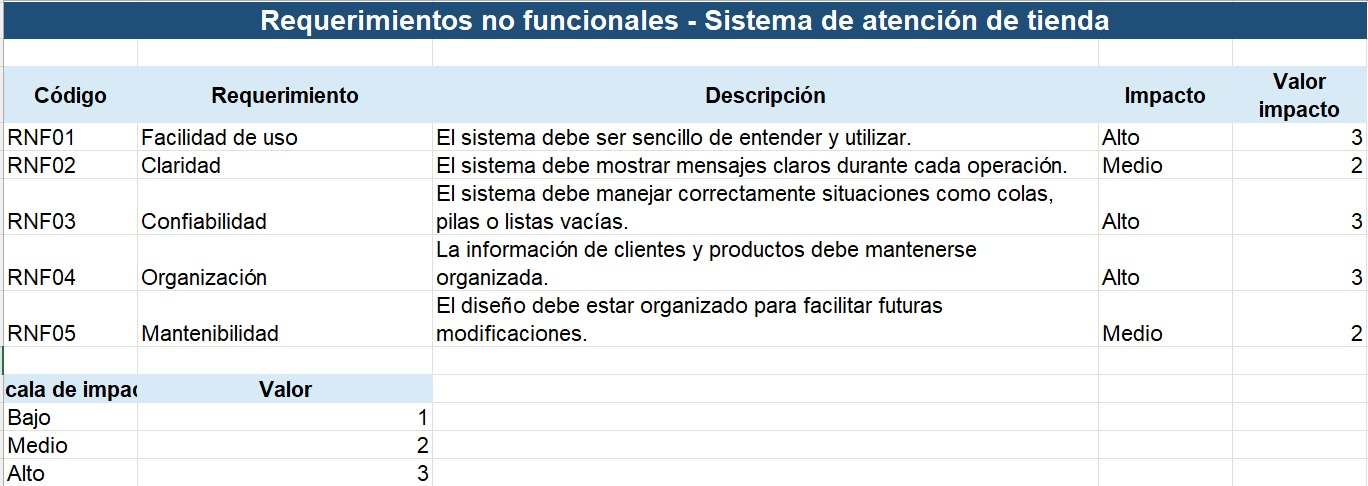

## 3) Historias de usuario **[2 pts]**

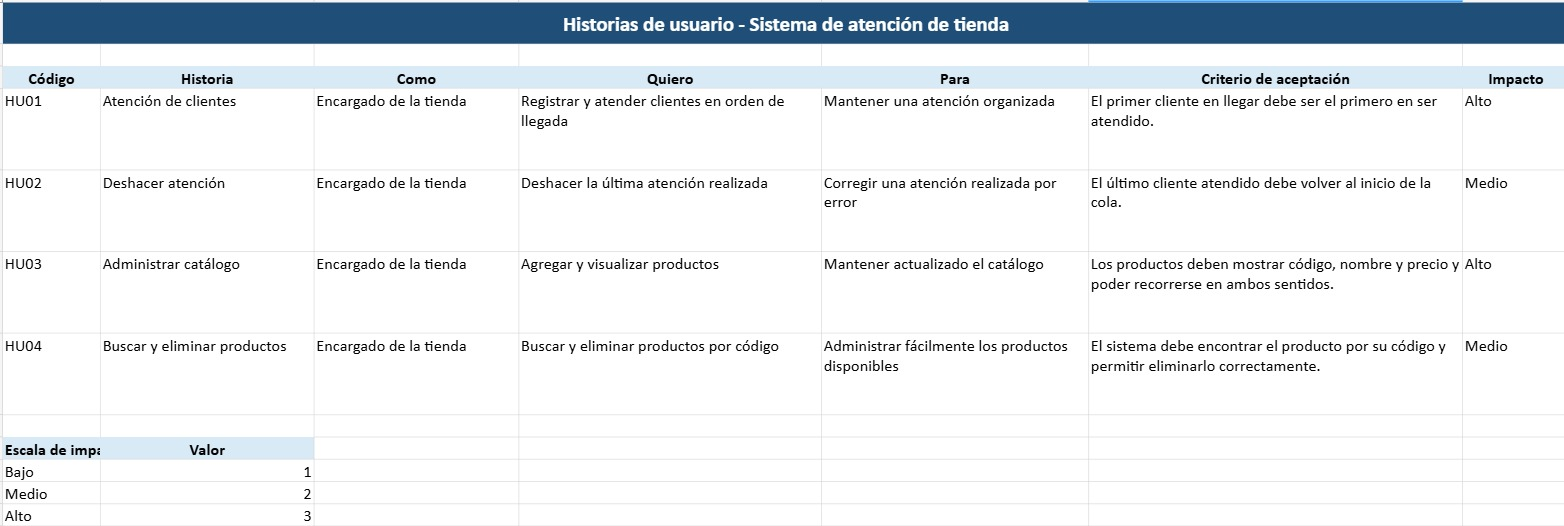

## 4) Diagramas de flujo **[5 pts]**

El flujo comienza con el registro de clientes. Luego se verifica si existen clientes esperando. Si existen, se atiende al primero y se guarda en la pila. Si no existen, el proceso termina. En el sistema completo, desde el menú también se pueden ejecutar las operaciones del catálogo de productos.

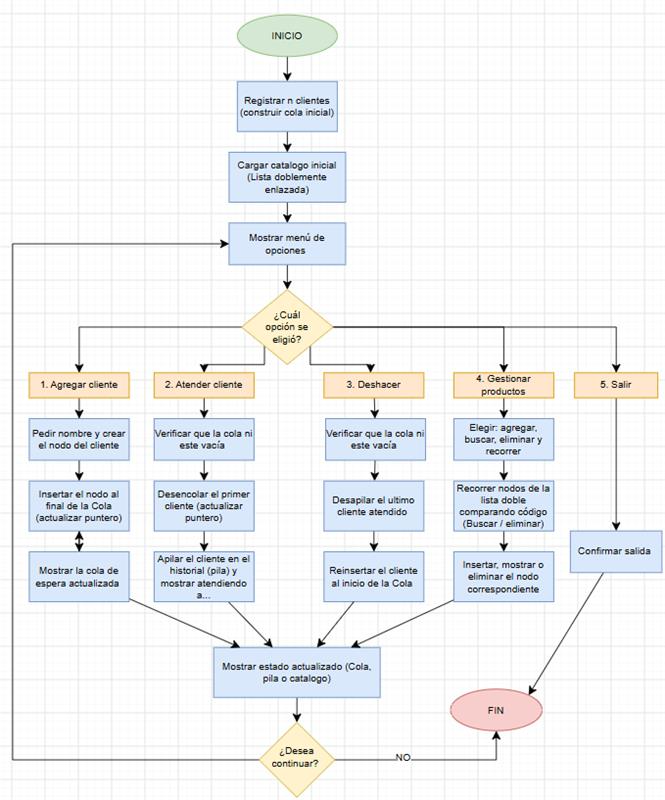

## 5) Diagramas de secuencia **[5 pts]**

El usuario solicita una operación al sistema. Para registrar un cliente, el sistema lo agrega a la cola. Para atenderlo, la cola entrega el primer cliente y el sistema lo guarda en la pila. Cuando se deshace una atención, el sistema obtiene el último elemento de la pila y lo devuelve al frente de la cola.

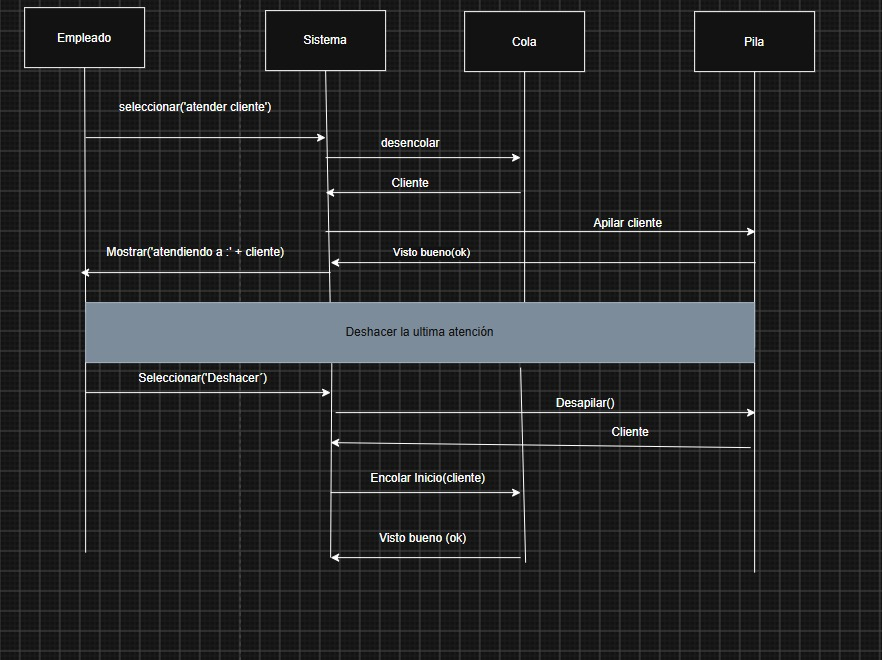


## 6) Diagramas de casos de uso **[5 pts]**

El empleado interactúa con las operaciones principales del sistema: registrar y atender clientes, deshacer una atención y administrar el catálogo. El cliente participa en el proceso de atención, mientras que el empleado es quien ejecuta las operaciones del sistema.

### Diagrama de caso de uso como encargado:
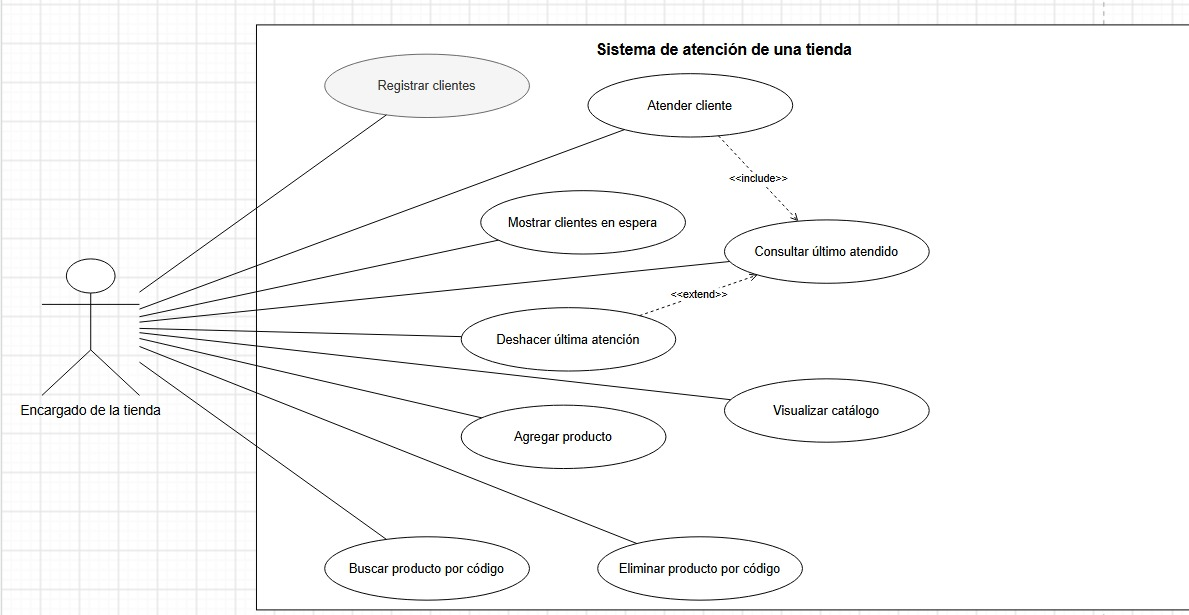

### Diagrama casos de uso como usuario:

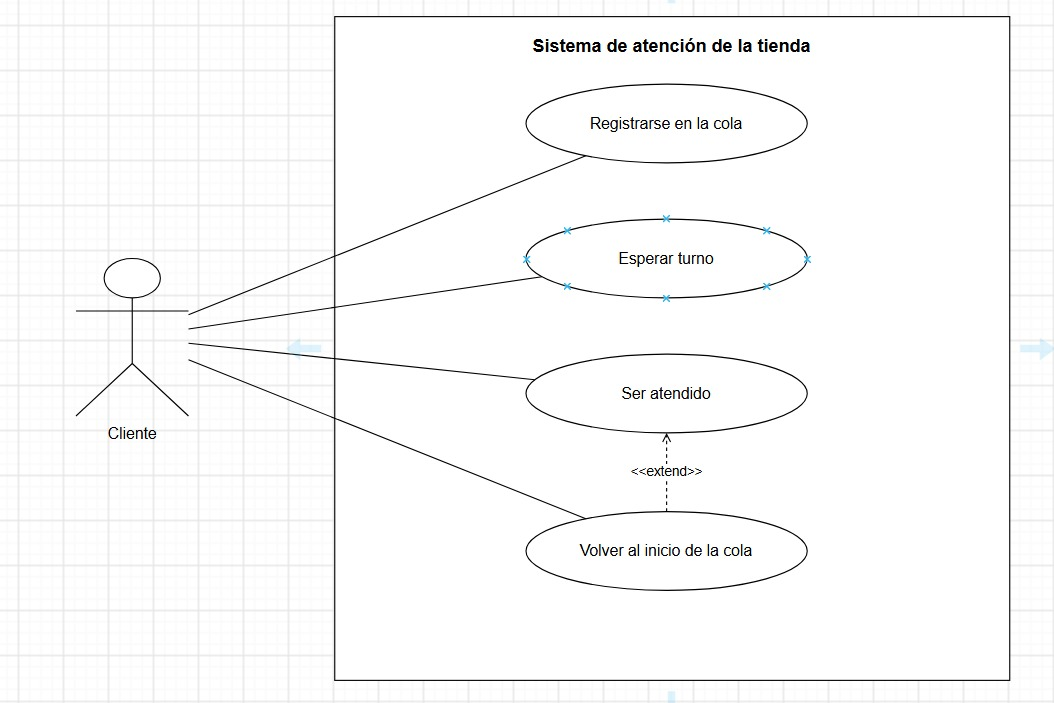


## 7) Análisis de complejidad **[5 pts]**

### Justificación

La operación que más interesa analizar es **buscar un producto por código**. Como la lista doblemente enlazada no está ordenada por código, en el peor caso se deben revisar todos los nodos.

- **Mejor caso:** el producto está en el primer nodo. Se realiza una sola comparación → **O(1)**.
- **Peor caso:** el producto está en el último nodo o no existe. Se recorren los `n` nodos → **O(n)**.

### Función T[n]

Para el peor caso podemos expresar la búsqueda como:

**T(n) = a·n + b**

donde `a` representa el costo de revisar cada nodo y `b` representa las operaciones constantes iniciales. Por lo tanto:

**T(n) = O(n)**.

Para el mejor caso:

**T(n) = c**

y por tanto:

**T(n) = O(1)**.

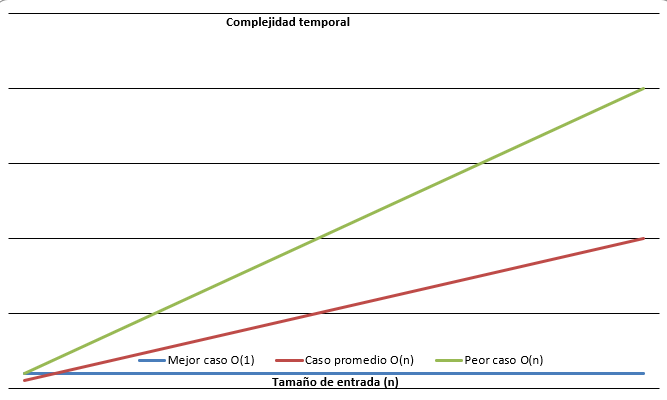


## 8) Código funcional **[10 pts]**




In [1]:
from dataclasses import dataclass

# ---------------- COLA DE CLIENTES ----------------

class ColaClientes:
    def __init__(self):
        self.clientes = []

    def agregar(self, nombre):
        """Agrega un cliente al final de la cola."""
        self.clientes.append(nombre)

    def atender(self):
        """Atiende y retira al primer cliente."""
        if not self.clientes:
            return None
        return self.clientes.pop(0)

    def agregar_al_frente(self, nombre):
        """Devuelve un cliente al inicio de la cola."""
        self.clientes.insert(0, nombre)

    def mostrar(self):
        return self.clientes.copy()

    def __len__(self):
        return len(self.clientes)


# ---------------- PILA DE OPERACIONES ----------------

class PilaOperaciones:
    def __init__(self):
        self.pila = []

    def push(self, cliente):
        self.pila.append(cliente)

    def pop(self):
        if not self.pila:
            return None
        return self.pila.pop()

    def mostrar(self):
        return self.pila.copy()


# ---------------- LISTA DOBLEMENTE ENLAZADA ----------------

@dataclass
class Producto:
    codigo: int
    nombre: str
    precio: float


class NodoProducto:
    def __init__(self, producto):
        self.producto = producto
        self.anterior = None
        self.siguiente = None


class ListaDobleProductos:
    def __init__(self):
        self.primero = None
        self.ultimo = None
        self.tamano = 0

    def agregar_final(self, codigo, nombre, precio):
        nuevo = NodoProducto(Producto(codigo, nombre, precio))

        if self.primero is None:
            self.primero = nuevo
            self.ultimo = nuevo
        else:
            nuevo.anterior = self.ultimo
            self.ultimo.siguiente = nuevo
            self.ultimo = nuevo

        self.tamano += 1

    def recorrer_inicio_fin(self):
        productos = []
        actual = self.primero

        while actual is not None:
            productos.append(actual.producto)
            actual = actual.siguiente

        return productos

    def recorrer_fin_inicio(self):
        productos = []
        actual = self.ultimo

        while actual is not None:
            productos.append(actual.producto)
            actual = actual.anterior

        return productos

    def buscar_por_codigo(self, codigo):
        actual = self.primero

        while actual is not None:
            if actual.producto.codigo == codigo:
                return actual.producto
            actual = actual.siguiente

        return None

    def eliminar_primero(self):
        if self.primero is None:
            return None

        eliminado = self.primero.producto

        if self.primero == self.ultimo:
            self.primero = None
            self.ultimo = None
        else:
            self.primero = self.primero.siguiente
            self.primero.anterior = None

        self.tamano -= 1
        return eliminado

    def eliminar_ultimo(self):
        if self.ultimo is None:
            return None

        eliminado = self.ultimo.producto

        if self.primero == self.ultimo:
            self.primero = None
            self.ultimo = None
        else:
            self.ultimo = self.ultimo.anterior
            self.ultimo.siguiente = None

        self.tamano -= 1
        return eliminado

    def eliminar_por_codigo(self, codigo):
        actual = self.primero

        while actual is not None:
            if actual.producto.codigo == codigo:
                if actual.anterior is not None:
                    actual.anterior.siguiente = actual.siguiente
                else:
                    self.primero = actual.siguiente

                if actual.siguiente is not None:
                    actual.siguiente.anterior = actual.anterior
                else:
                    self.ultimo = actual.anterior

                self.tamano -= 1
                return actual.producto

            actual = actual.siguiente

        return None


# ---------------- SISTEMA COMPLETO ----------------

class SistemaTienda:
    def __init__(self):
        self.cola = ColaClientes()
        self.pila = PilaOperaciones()
        self.productos = ListaDobleProductos()

    def registrar_cliente(self, nombre):
        self.cola.agregar(nombre)

    def atender_cliente(self):
        cliente = self.cola.atender()

        if cliente is not None:
            self.pila.push(cliente)

        return cliente

    def deshacer_atencion(self):
        cliente = self.pila.pop()

        if cliente is not None:
            self.cola.agregar_al_frente(cliente)

        return cliente

    def agregar_producto(self, codigo, nombre, precio):
        self.productos.agregar_final(codigo, nombre, precio)

    def buscar_producto(self, codigo):
        return self.productos.buscar_por_codigo(codigo)


# ---------------- FUNCIONES AUXILIARES ----------------

def mostrar_productos(productos):
    if not productos:
        print("No hay productos.")
        return

    for p in productos:
        print(f"Codigo: {p.codigo} | Nombre: {p.nombre} | Precio: ${p.precio:,.0f}")


def mostrar_menu():
    print("\n--- SISTEMA DE ATENCION DE LA TIENDA ---")
    print("1. Registrar cliente")
    print("2. Atender cliente")
    print("3. Deshacer ultima atencion")
    print("4. Mostrar clientes esperando")
    print("5. Agregar producto")
    print("6. Mostrar productos inicio -> fin")
    print("7. Mostrar productos fin -> inicio")
    print("8. Buscar producto por codigo")
    print("9. Eliminar primer producto")
    print("10. Eliminar ultimo producto")
    print("11. Eliminar producto por codigo")
    print("0. Salir")


# ---------------- MAIN ----------------

def main():
    sistema = SistemaTienda()

    while True:
        mostrar_menu()
        opcion = input("Seleccione una opcion: ")

        if opcion == "1":
            nombre = input("Nombre del cliente: ").strip()

            if nombre:
                sistema.registrar_cliente(nombre)
                print("Cliente agregado.")
            else:
                print("El nombre no puede estar vacio.")

        elif opcion == "2":
            cliente = sistema.atender_cliente()

            if cliente is not None:
                print("Atendiendo:", cliente)
            else:
                print("No hay clientes para atender.")

        elif opcion == "3":
            cliente = sistema.deshacer_atencion()

            if cliente is not None:
                print("Atencion deshecha:", cliente)
            else:
                print("No hay atenciones para deshacer.")

        elif opcion == "4":
            clientes = sistema.cola.mostrar()

            if clientes:
                print("Clientes esperando:", " -> ".join(clientes))
            else:
                print("No hay clientes esperando.")

        elif opcion == "5":
            try:
                codigo = int(input("Codigo del producto: "))
                nombre = input("Nombre del producto: ").strip()
                precio = float(input("Precio del producto: "))

                if nombre:
                    sistema.agregar_producto(codigo, nombre, precio)
                    print("Producto agregado.")
                else:
                    print("El nombre del producto no puede estar vacio.")

            except ValueError:
                print("El codigo debe ser entero y el precio debe ser numerico.")

        elif opcion == "6":
            productos = sistema.productos.recorrer_inicio_fin()
            mostrar_productos(productos)

        elif opcion == "7":
            productos = sistema.productos.recorrer_fin_inicio()
            mostrar_productos(productos)

        elif opcion == "8":
            try:
                codigo = int(input("Codigo a buscar: "))
                producto = sistema.buscar_producto(codigo)

                if producto is not None:
                    mostrar_productos([producto])
                else:
                    print("Producto no encontrado.")

            except ValueError:
                print("El codigo debe ser un numero entero.")

        elif opcion == "9":
            producto = sistema.productos.eliminar_primero()

            if producto is not None:
                print("Producto eliminado:")
                mostrar_productos([producto])
            else:
                print("No hay productos para eliminar.")

        elif opcion == "10":
            producto = sistema.productos.eliminar_ultimo()

            if producto is not None:
                print("Producto eliminado:")
                mostrar_productos([producto])
            else:
                print("No hay productos para eliminar.")

        elif opcion == "11":
            try:
                codigo = int(input("Codigo a eliminar: "))
                producto = sistema.productos.eliminar_por_codigo(codigo)

                if producto is not None:
                    print("Producto eliminado:")
                    mostrar_productos([producto])
                else:
                    print("Producto no encontrado.")

            except ValueError:
                print("El codigo debe ser un numero entero.")

        elif opcion == "0":
            print("Programa finalizado.")
            break

        else:
            print("Opcion invalida. Intente nuevamente.")


if __name__ == "__main__":
    main()


--- SISTEMA DE ATENCION DE LA TIENDA ---
1. Registrar cliente
2. Atender cliente
3. Deshacer ultima atencion
4. Mostrar clientes esperando
5. Agregar producto
6. Mostrar productos inicio -> fin
7. Mostrar productos fin -> inicio
8. Buscar producto por codigo
9. Eliminar primer producto
10. Eliminar ultimo producto
11. Eliminar producto por codigo
0. Salir
Seleccione una opcion: 1
Nombre del cliente: Juan
Cliente agregado.

--- SISTEMA DE ATENCION DE LA TIENDA ---
1. Registrar cliente
2. Atender cliente
3. Deshacer ultima atencion
4. Mostrar clientes esperando
5. Agregar producto
6. Mostrar productos inicio -> fin
7. Mostrar productos fin -> inicio
8. Buscar producto por codigo
9. Eliminar primer producto
10. Eliminar ultimo producto
11. Eliminar producto por codigo
0. Salir
Seleccione una opcion: 2
Atendiendo: Juan

--- SISTEMA DE ATENCION DE LA TIENDA ---
1. Registrar cliente
2. Atender cliente
3. Deshacer ultima atencion
4. Mostrar clientes esperando
5. Agregar producto
6. Mostrar p

## 9) Pruebas **[15 pts]**




In [23]:
def test(resultado_obtenido, resultado_esperado):
    assert resultado_obtenido == resultado_esperado, (
        f"se obtuvo {resultado_obtenido}, pero se esperaba {resultado_esperado}"
    )
    print(f"Paso caso de prueba: {resultado_obtenido} -> {resultado_esperado}")

## Pruebas de enunciado




In [24]:
# Pruebas de enunciado

s = SistemaTienda()

for nombre in ["Ana", "Carlos", "Laura", "Mateo"]:
    s.registrar_cliente(nombre)

test(s.cola.mostrar(), ["Ana", "Carlos", "Laura", "Mateo"])

test(s.atender_cliente(), "Ana")
test(s.atender_cliente(), "Carlos")

test(s.cola.mostrar(), ["Laura", "Mateo"])
test(s.pila.mostrar(), ["Ana", "Carlos"])

test(s.deshacer_atencion(), "Carlos")
test(s.cola.mostrar(), ["Carlos", "Laura", "Mateo"])

print("Pruebas del enunciado: OK")

Paso caso de prueba: ['Ana', 'Carlos', 'Laura', 'Mateo'] -> ['Ana', 'Carlos', 'Laura', 'Mateo']
Paso caso de prueba: Ana -> Ana
Paso caso de prueba: Carlos -> Carlos
Paso caso de prueba: ['Laura', 'Mateo'] -> ['Laura', 'Mateo']
Paso caso de prueba: ['Ana', 'Carlos'] -> ['Ana', 'Carlos']
Paso caso de prueba: Carlos -> Carlos
Paso caso de prueba: ['Carlos', 'Laura', 'Mateo'] -> ['Carlos', 'Laura', 'Mateo']
Pruebas del enunciado: OK


## Pruebas propias




In [25]:
# Pruebas propias: lista doblemente enlazada

s = SistemaTienda()

s.agregar_producto(101, "Arroz", 4500)
s.agregar_producto(102, "Leche", 3800)
s.agregar_producto(103, "Pan", 2500)
s.agregar_producto(104, "Cafe", 12000)

test([p.codigo for p in s.productos.recorrer_inicio_fin()], [101, 102, 103, 104])
test([p.codigo for p in s.productos.recorrer_fin_inicio()], [104, 103, 102, 101])

producto = s.buscar_producto(103)
test(producto.nombre, "Pan")
test(producto.precio, 2500)

eliminado = s.productos.eliminar_por_codigo(103)
test(eliminado.codigo, 103)
test([p.codigo for p in s.productos.recorrer_inicio_fin()], [101, 102, 104])

test(s.productos.eliminar_por_codigo(999), None)

primero = s.productos.eliminar_primero()
test(primero.codigo, 101)

ultimo = s.productos.eliminar_ultimo()
test(ultimo.codigo, 104)

test([p.codigo for p in s.productos.recorrer_inicio_fin()], [102])

print("Pruebas propias: OK")

Paso caso de prueba: [101, 102, 103, 104] -> [101, 102, 103, 104]
Paso caso de prueba: [104, 103, 102, 101] -> [104, 103, 102, 101]
Paso caso de prueba: Pan -> Pan
Paso caso de prueba: 2500 -> 2500
Paso caso de prueba: 103 -> 103
Paso caso de prueba: [101, 102, 104] -> [101, 102, 104]
Paso caso de prueba: None -> None
Paso caso de prueba: 101 -> 101
Paso caso de prueba: 104 -> 104
Paso caso de prueba: [102] -> [102]
Pruebas propias: OK


## Pruebas de Desempeño




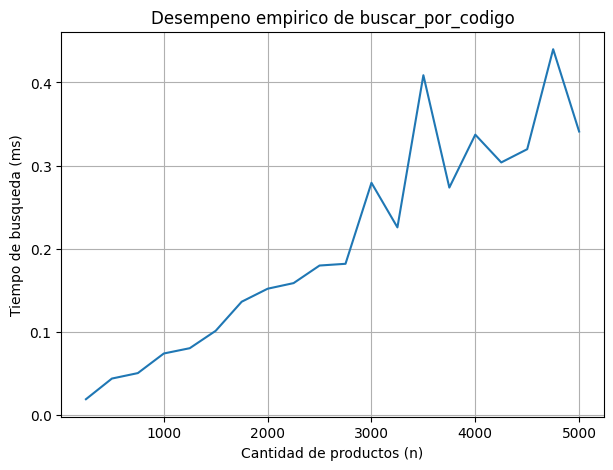

Pruebas de desempeno: OK


In [22]:
import time

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None


def preparar_lista(n):
    lista = ListaDobleProductos()

    for i in range(n):
        lista.agregar_final(i, f"Producto {i}", i * 1000)

    return lista


def bench(n, step=100):
    resultados = []

    for size in range(step, n + 1, step):
        lista = preparar_lista(size)

        # Peor caso: el codigo no existe, entonces se recorre toda la lista.
        inicio = time.perf_counter()
        lista.buscar_por_codigo(-1)
        fin = time.perf_counter()

        tiempo_ms = (fin - inicio) * 1000
        resultados.append((size, tiempo_ms))

    return resultados


tiempos = bench(5000, step=250)

x = [size for size, tiempo in tiempos]
y = [tiempo for size, tiempo in tiempos]

if plt is not None:
    plt.figure(figsize=(7, 5))
    plt.plot(x, y)
    plt.xlabel("Cantidad de productos (n)")
    plt.ylabel("Tiempo de busqueda (ms)")
    plt.title("Desempeno empirico de buscar_por_codigo")
    plt.grid(True)
    plt.show()
else:
    print("matplotlib no esta instalado. Se muestran los tiempos medidos:")
    print("n | tiempo de busqueda (ms)")

    for size, tiempo in tiempos:
        print(f"{size} | {tiempo:.6f}")

print("Pruebas de desempeno: OK")